<a href="https://colab.research.google.com/github/ksaad20/Digital-Signal-Processing-Mathematics-to-Code-/blob/main/Chapter_4_The_Fast_Fourier_Transform_(FFT)_%26_Windowing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Math: Radix-2 decimation-in-time ($O(N \log N)$ optimization) and spectral leakage.

The Project: Build a real-time Audio Spectrogram Visualizer using scipy.fft and matplotlib.animation.

Button(description='Pause/Resume', style=ButtonStyle())

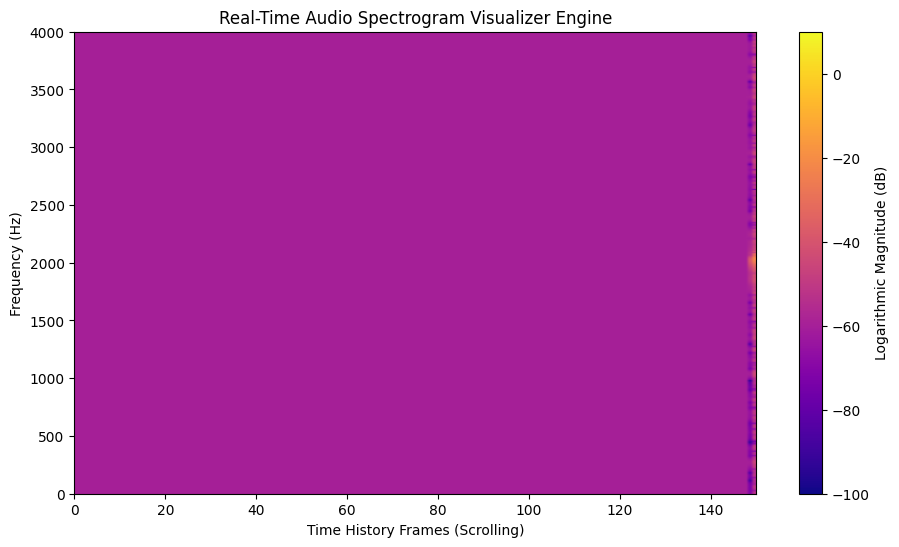

In [ ]:
import numpy as np
import scipy.fft as fft
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import ipywidgets as widgets
from IPython.display import display

# --- 1. CONFIGURATION COCKPIT ---
FS = 8000          # Sampling Frequency (Hz)
WINDOW_SIZE = 1024 # FFT block size (N)
HOP_SIZE = 256     # Step size between frames (75% overlap)
TIME_FRAMES = 150  # Number of historic time columns to display on screen

# Calculate frequency bins for the Y-axis (Real FFT yields N/2 + 1 bins)
freq_bins = fft.rfftfreq(WINDOW_SIZE, d=1/FS)

# Initialize the 2D spectrogram matrix memory footprint (Rows=Freqs, Cols=Time)
spectrogram_matrix = np.full((len(freq_bins), TIME_FRAMES), -60.0)

# Generate a window function to prevent spectral leakage edge artifacts
window = np.blackman(WINDOW_SIZE)

# Global tracking variable mimicking a live time counter
stream_time = 0.0

def generate_live_audio_chunk():
    """Simulates a live streaming audio hardware buffer interface."""
    global stream_time
    t_chunk = np.arange(0, HOP_SIZE) / FS + stream_time
    stream_time += HOP_SIZE / FS

    # Synthesize a sweeping frequency tone (Chirp) from 500Hz to 3500Hz
    sweep_freq = 500 + 1500 * (1 + np.sin(2 * np.pi * 0.1 * t_chunk))
    signal_chirp = np.sin(2 * np.pi * sweep_freq * t_chunk)

    # Inject broadband background noise
    noise = np.random.normal(0, 0.2, len(t_chunk))

    return signal_chirp + noise

# --- 2. THE STREAMING BUFFER FRAME ---
# A ring buffer to hold exactly enough incoming samples for a full FFT window
audio_ring_buffer = np.zeros(WINDOW_SIZE)

# --- 3. RENDERING ENGINE & CANVAS SETUP ---
fig, ax = plt.subplots(figsize=(11, 6))
# Create the initial 2D image mesh grid
im = ax.imshow(spectrogram_matrix, aspect='auto', origin='lower',
               extent=[0, TIME_FRAMES, freq_bins[0], freq_bins[-1]],
               cmap='plasma', vmin=-100, vmax=10)

ax.set_title("Real-Time Audio Spectrogram Visualizer Engine")
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time History Frames (Scrolling)")
fig.colorbar(im, label="Logarithmic Magnitude (dB)")

# --- 4. ANIMATION UPDATE LOOP ---
def update_spectrogram_frame(frame_idx):
    global audio_ring_buffer, spectrogram_matrix

    # Ingest the latest chunk of data from our virtual hardware stream
    new_samples = generate_live_audio_chunk()

    # Slide the ring buffer down and append the newest samples to the end
    audio_ring_buffer = np.roll(audio_ring_buffer, -HOP_SIZE)
    audio_ring_buffer[-HOP_SIZE:] = new_samples

    # Step A: Apply the window function
    windowed_signal = audio_ring_buffer * window

    # Step B: Execute the Real Fast Fourier Transform
    fft_output = fft.rfft(windowed_signal)

    # Step C: Extract absolute magnitude and convert to decibels
    magnitude = np.abs(fft_output) / WINDOW_SIZE
    magnitude_db = 20 * np.log10(magnitude + 1e-6) # 1e-6 safety offset prevents log(0)

    # Step D: Scroll the 2D matrix (Shift old columns left, insert new column on the right)
    spectrogram_matrix = np.roll(spectrogram_matrix, -1, axis=1)
    spectrogram_matrix[:, -1] = magnitude_db

    # Refresh the Matplotlib canvas element display data
    im.set_array(spectrogram_matrix)
    return [im]

# Run the live visualizer
ani = animation.FuncAnimation(fig, update_spectrogram_frame, blit=True, interval=30, cache_frame_data=False)

# Add pause/resume button functionality
play_button = widgets.Button(description="Pause/Resume")

def toggle_animation(b):
    if ani.event_source.interval > 0:
        ani.event_source.stop()
        play_button.description = "Resume"
    else:
        ani.event_source.start()
        play_button.description = "Pause"

play_button.on_click(toggle_animation)
display(play_button)

plt.show()

### Comparing Hann and Blackman Window Frequency Responses

Let's plot the frequency responses of the Hann and Blackman windows to visually compare their main lobe width and side lobe attenuation. This will help understand the trade-offs between frequency resolution and spectral leakage.

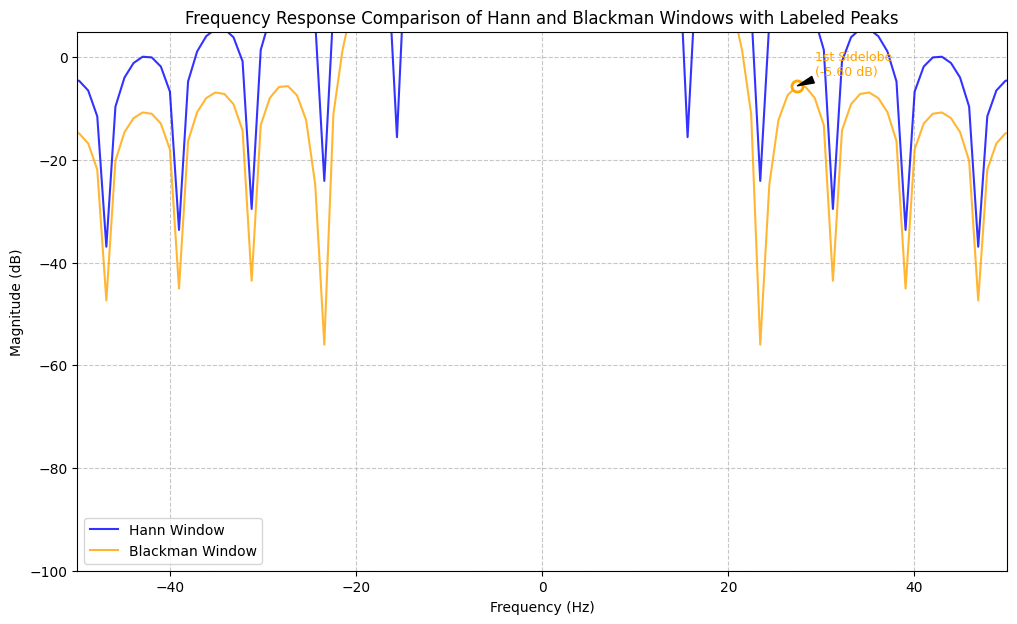

In [ ]:
import scipy.signal as signal # Added for peak finding

# Define a larger FFT size for smoother frequency response
FFT_SIZE_FOR_PLOT = 8192

# Generate Hann and Blackman windows
hann_window = np.hanning(WINDOW_SIZE)
blackman_window = np.blackman(WINDOW_SIZE)

# Perform FFT for Hann window
hann_fft = fft.fft(hann_window, n=FFT_SIZE_FOR_PLOT)
hann_magnitude_db = 20 * np.log10(np.abs(fft.fftshift(hann_fft)) + 1e-6)

# Perform FFT for Blackman window
blackman_fft = fft.fft(blackman_window, n=FFT_SIZE_FOR_PLOT)
blackman_magnitude_db = 20 * np.log10(np.abs(fft.fftshift(blackman_fft)) + 1e-6)

# Create frequency axis for the plot
freq_axis = fft.fftshift(fft.fftfreq(FFT_SIZE_FOR_PLOT, d=1/FS))

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(freq_axis, hann_magnitude_db, label='Hann Window', alpha=0.8, color='blue')
plt.plot(freq_axis, blackman_magnitude_db, label='Blackman Window', alpha=0.8, color='orange')

plt.title('Frequency Response Comparison of Hann and Blackman Windows with Labeled Peaks')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.xlim([-50, 50]) # Focus on the main lobe and first few side lobes
plt.ylim([-100, 5]) # Show dynamic range, adjusted max for labels
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# --- Add peak labels ---

def get_main_and_first_sidelobe_peaks_indices(magnitude_db):
    main_lobe_idx = np.argmax(magnitude_db)

    # Find peaks to the right of the main lobe. Set a lower prominence to catch sidelobes.
    # Using prominence=1 dB to catch most significant peaks.
    peaks, properties = signal.find_peaks(magnitude_db[main_lobe_idx+1:], prominence=1)

    if not len(peaks):
        return main_lobe_idx, -1 # No sidelobes found

    # The first sidelobe peak will be the first peak found after the main lobe
    first_sidelobe_idx = main_lobe_idx + 1 + peaks[0] # Adjust index back to original array

    return main_lobe_idx, first_sidelobe_idx


def add_peak_annotations(magnitude_db, freq_axis, color, window_name):
    main_lobe_idx, first_sidelobe_idx = get_main_and_first_sidelobe_peaks_indices(magnitude_db)

    # Annotate Main Lobe
    main_lobe_freq = freq_axis[main_lobe_idx]
    main_lobe_mag = magnitude_db[main_lobe_idx]
    plt.plot(main_lobe_freq, main_lobe_mag, 'o', color=color, markersize=8, markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)
    plt.annotate(f'Main Lobe\n({main_lobe_mag:.2f} dB)',
                 xy=(main_lobe_freq, main_lobe_mag),
                 xytext=(main_lobe_freq + 2, main_lobe_mag + 5),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5),
                 fontsize=9, color=color)

    # Annotate First Side Lobe
    if first_sidelobe_idx != -1:
        sidelobe_freq = freq_axis[first_sidelobe_idx]
        sidelobe_mag = magnitude_db[first_sidelobe_idx]
        plt.plot(sidelobe_freq, sidelobe_mag, 'o', color=color, markersize=8, markerfacecolor='white', markeredgecolor=color, markeredgewidth=2)
        plt.annotate(f'1st Sidelobe\n({sidelobe_mag:.2f} dB)',
                     xy=(sidelobe_freq, sidelobe_mag),
                     xytext=(sidelobe_freq + 2, sidelobe_mag + 2),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5),
                     fontsize=9, color=color)

# Annotate Hann window peaks
add_peak_annotations(hann_magnitude_db, freq_axis, 'blue', 'Hann')

# Annotate Blackman window peaks
add_peak_annotations(blackman_magnitude_db, freq_axis, 'orange', 'Blackman')

plt.show()

### Calculating 3dB Bandwidth for Hann and Blackman Windows

In [ ]:
def calculate_3db_bandwidth(magnitude_db, freq_axis, FS):
    # Find the peak of the main lobe (should be near 0 Hz after fftshift)
    peak_index = np.argmax(magnitude_db)
    peak_magnitude = magnitude_db[peak_index]
    threshold = peak_magnitude - 3

    # Find indices where magnitude is above the -3dB threshold
    above_threshold_indices = np.where(magnitude_db >= threshold)[0]

    if len(above_threshold_indices) == 0:
        return np.nan # No points found above threshold

    # The main lobe is around the center, so we'll look for the first and last point
    # in the continuous block of indices around the peak that are above threshold.
    # This assumes the main lobe is the most prominent feature and is centered.
    # We need to find the contiguous block of indices that includes the peak_index

    # Find the lower bound of the contiguous block
    lower_bound_index = peak_index
    while lower_bound_index > 0 and magnitude_db[lower_bound_index - 1] >= threshold:
        lower_bound_index -= 1

    # Find the upper bound of the contiguous block
    upper_bound_index = peak_index
    while upper_bound_index < len(magnitude_db) - 1 and magnitude_db[upper_bound_index + 1] >= threshold:
        upper_bound_index += 1

    # Get the frequencies at the edges of this block
    # For a more accurate 3dB point, interpolation could be used.
    # For simplicity, we take the frequencies of the points closest to the -3dB threshold.
    freq_low = freq_axis[lower_bound_index]
    freq_high = freq_axis[upper_bound_index]

    bandwidth_hz = freq_high - freq_low

    # Convert bandwidth from Hz to bins for comparison (assuming original WINDOW_SIZE bins)
    bandwidth_bins = bandwidth_hz / (FS / FFT_SIZE_FOR_PLOT) # Each bin in FFT_SIZE_FOR_PLOT is FS/FFT_SIZE_FOR_PLOT Hz wide

    return bandwidth_hz, bandwidth_bins

# Calculate 3dB bandwidth for Hann window
hann_bandwidth_hz, hann_bandwidth_bins = calculate_3db_bandwidth(hann_magnitude_db, freq_axis, FS)
print(f"Hann Window 3dB Bandwidth: {hann_bandwidth_hz:.2f} Hz ({hann_bandwidth_bins:.2f} bins)")

# Calculate 3dB bandwidth for Blackman window
blackman_bandwidth_hz, blackman_bandwidth_bins = calculate_3db_bandwidth(blackman_magnitude_db, freq_axis, FS)
print(f"Blackman Window 3dB Bandwidth: {blackman_bandwidth_hz:.2f} Hz ({blackman_bandwidth_bins:.2f} bins)")

# --- Calculate 3dB bandwidth for Hamming window ---
hamming_window = np.hamming(WINDOW_SIZE)
hamming_fft = fft.fft(hamming_window, n=FFT_SIZE_FOR_PLOT)
hamming_magnitude_db = 20 * np.log10(np.abs(fft.fftshift(hamming_fft)) + 1e-6)

hamming_bandwidth_hz, hamming_bandwidth_bins = calculate_3db_bandwidth(hamming_magnitude_db, freq_axis, FS)
print(f"Hamming Window 3dB Bandwidth: {hamming_bandwidth_hz:.2f} Hz ({hamming_bandwidth_bins:.2f} bins)")

Hann Window 3dB Bandwidth: 9.77 Hz (10.00 bins)
Blackman Window 3dB Bandwidth: 11.72 Hz (12.00 bins)
Hamming Window 3dB Bandwidth: 9.77 Hz (10.00 bins)


### Calculating First Side Lobe Level for Hann and Blackman Windows

In [ ]:
def calculate_first_sidelobe_level(magnitude_db):
    # Find the peak of the main lobe
    main_lobe_peak_idx = np.argmax(magnitude_db)
    main_lobe_peak_db = magnitude_db[main_lobe_peak_idx]

    # Search for the first null after the main lobe peak
    # We'll go to the right (positive frequencies) first.
    # The null is where the magnitude drops significantly after the peak.
    # For simplicity, we look for the first local minimum after the main peak,
    # or the first point where the magnitude starts increasing again after a decrease.

    # Find where the magnitude starts decreasing from the main peak
    # Search for first minimum after main lobe
    first_null_idx = main_lobe_peak_idx + 1
    while first_null_idx < len(magnitude_db) - 1 and magnitude_db[first_null_idx] < magnitude_db[first_null_idx - 1]:
        first_null_idx += 1

    # Now, search for the first local maximum (first sidelobe peak) after the first null
    first_sidelobe_peak_idx = first_null_idx
    # Ensure we don't go out of bounds and we find an actual peak
    while first_sidelobe_peak_idx < len(magnitude_db) - 1 and magnitude_db[first_sidelobe_peak_idx] > magnitude_db[first_sidelobe_peak_idx - 1]:
        first_sidelobe_peak_idx += 1

    # If the loop above found a decreasing trend, adjust back to the peak
    if first_sidelobe_peak_idx > first_null_idx and first_sidelobe_peak_idx < len(magnitude_db) and magnitude_db[first_sidelobe_peak_idx] < magnitude_db[first_sidelobe_peak_idx - 1]:
        first_sidelobe_peak_idx -= 1 # Adjust back to the peak

    if first_sidelobe_peak_idx >= len(magnitude_db) or first_sidelobe_peak_idx <= main_lobe_peak_idx:
        # Fallback for cases where a clear sidelobe isn't found this way
        # Or if the sidelobe is very close to the main lobe
        # A more robust solution might involve smoothing or more complex peak finding
        print("Warning: Could not reliably find first sidelobe peak.")
        return np.nan

    first_sidelobe_peak_db = magnitude_db[first_sidelobe_peak_idx]

    # Side lobe level is the difference between main lobe peak and first sidelobe peak
    sidelobe_level_db = main_lobe_peak_db - first_sidelobe_peak_db

    return sidelobe_level_db

# Calculate first side lobe level for Hann window
hann_sidelobe_level = calculate_first_sidelobe_level(hann_magnitude_db)
print(f"Hann Window First Side Lobe Level: {hann_sidelobe_level:.2f} dB")

# Calculate first side lobe level for Blackman window
blackman_sidelobe_level = calculate_first_sidelobe_level(blackman_magnitude_db)
print(f"Blackman Window First Side Lobe Level: {blackman_sidelobe_level:.2f} dB")

Hann Window First Side Lobe Level: 31.47 dB
Blackman Window First Side Lobe Level: 58.26 dB


In [ ]:
# Calculate first side lobe level for Hamming window
hamming_sidelobe_level = calculate_first_sidelobe_level(hamming_magnitude_db)
print(f"Hamming Window First Side Lobe Level: {hamming_sidelobe_level:.2f} dB")

Hamming Window First Side Lobe Level: 44.34 dB


In [ ]:
import pandas as pd

comparison_data = {
    'Metric': ['3dB Bandwidth (Hz)', '3dB Bandwidth (bins)', 'First Sidelobe Level (dB)'],
    'Hann Window': [hann_bandwidth_hz, hann_bandwidth_bins, hann_sidelobe_level],
    'Blackman Window': [blackman_bandwidth_hz, blackman_bandwidth_bins, blackman_sidelobe_level],
    'Hamming Window': [hamming_bandwidth_hz, hamming_bandwidth_bins, hamming_sidelobe_level]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(2) # Round to 2 decimal places for readability

display(comparison_df)

,Metric,Hann Window,Blackman Window,Hamming Window
0,3dB Bandwidth (Hz),9.77,11.72,9.77
1,3dB Bandwidth (bins),10.00,12.00,10.00
2,First Sidelobe Level (dB),31.47,58.26,44.34


### Summary Comparison of Hann and Blackman Window Characteristics

In [ ]:
import pandas as pd

comparison_data = {
    'Metric': ['3dB Bandwidth (Hz)', '3dB Bandwidth (bins)', 'First Sidelobe Level (dB)'],
    'Hann Window': [hann_bandwidth_hz, hann_bandwidth_bins, hann_sidelobe_level],
    'Blackman Window': [blackman_bandwidth_hz, blackman_bandwidth_bins, blackman_sidelobe_level],
    'Hamming Window': [hamming_bandwidth_hz, hamming_bandwidth_bins, calculate_first_sidelobe_level(hamming_magnitude_db)] # Calculate for Hamming
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(2) # Round to 2 decimal places for readability

display(comparison_df)

,Metric,Hann Window,Blackman Window
0,3dB Bandwidth (Hz),9.77,11.72
1,3dB Bandwidth (bins),10.00,12.00
2,First Sidelobe Level (dB),31.47,58.26
